In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader , random_split 


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
dataset = MNIST(root = 'data/',download = True)

In [4]:
len(dataset)

60000

In [5]:
test_dataset = MNIST(root = 'data/',train = False)

In [6]:
len(test_dataset)

10000

Label:  5


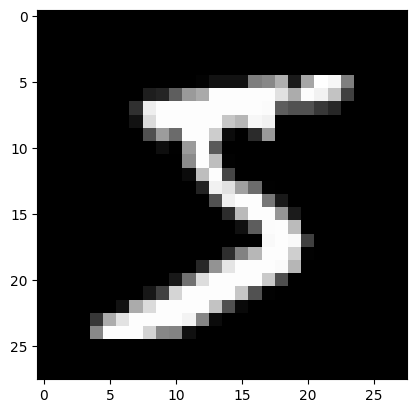

In [7]:
img , label = dataset[0]
plt.imshow(img , cmap = "grey")
print("Label: ",label)

Label:  3


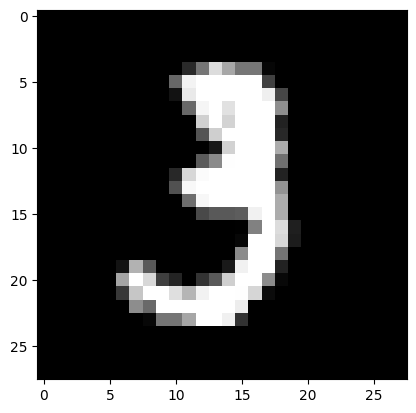

In [8]:
img , label = dataset[10]
plt.imshow(img , cmap = "grey")
print("Label: ",label)

Label:  1


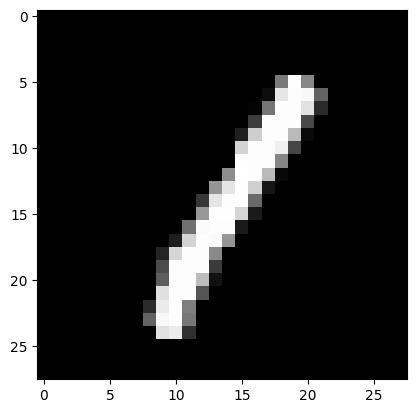

In [9]:
img , label = dataset[23]
plt.imshow(img , cmap = "grey")
print("Label: ",label)

In [10]:
dataset = MNIST(root = 'data/',train = True , transform = transforms.ToTensor())

Label:  5


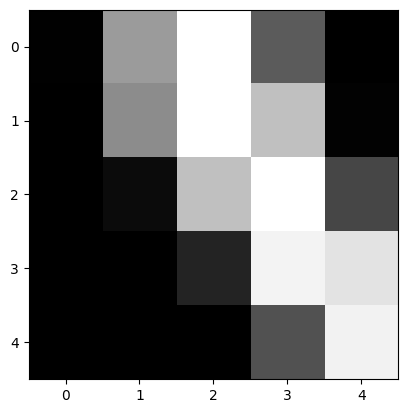

In [11]:
img_tensor ,label =  dataset[0]
plt.imshow(img_tensor[0,10:15,10:15] , cmap='grey')
print("Label: ",label)

Label:  0


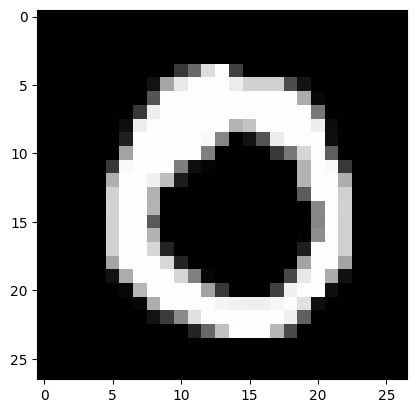

In [12]:
img_tensor ,label =  dataset[56]
plt.imshow(img_tensor[0,1:28,1:28] , cmap='grey')
print("Label: ",label)

In [13]:
maxs ,mins = torch.max(img_tensor) ,torch.min(img_tensor)
print(maxs)
print(mins)

tensor(1.)
tensor(0.)


In [14]:
test_dataset = MNIST(root = 'data/',train = False ,transform = transforms.ToTensor())

In [15]:
train_ds , val_ds = random_split(dataset , [50000,10000])


In [16]:
print(len(train_ds))
print(len(val_ds))

50000
10000


In [17]:
train_loader = DataLoader(train_ds , batch_size = 128 , shuffle = True)

In [18]:
val_loader = DataLoader(val_ds , batch_size = 128)

In [19]:
input_size = 28*28*1 
num_class = 10 # from 0 to 9
model = nn.Linear(input_size , num_class)
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[-0.0078, -0.0138, -0.0291,  ...,  0.0012,  0.0192, -0.0295],
        [ 0.0090, -0.0168, -0.0304,  ..., -0.0073,  0.0131,  0.0011],
        [-0.0080, -0.0131,  0.0066,  ..., -0.0207,  0.0045,  0.0233],
        ...,
        [-0.0170, -0.0021,  0.0077,  ...,  0.0287, -0.0240, -0.0346],
        [-0.0008, -0.0138, -0.0075,  ...,  0.0045, -0.0069, -0.0222],
        [-0.0321,  0.0263, -0.0349,  ...,  0.0339, -0.0111,  0.0191]],
       requires_grad=True)
Parameter containing:
tensor([ 0.0212,  0.0016,  0.0011,  0.0284,  0.0324, -0.0238, -0.0241,  0.0078,
         0.0043, -0.0180], requires_grad=True)


In [21]:
for image , label in train_loader:
    print(image.shape)
    print(label)
    preds = model(image)
    break
# this is not possible because the nn.Linear model expect the input_size to be a 2 - dimentional array not a 4 - dimentional array .so replace is needed

torch.Size([128, 1, 28, 28])
tensor([5, 6, 6, 8, 6, 8, 0, 1, 6, 6, 2, 5, 1, 0, 4, 5, 3, 1, 9, 5, 5, 2, 9, 4,
        3, 8, 8, 1, 0, 7, 4, 1, 6, 9, 0, 3, 8, 0, 0, 9, 7, 5, 2, 2, 8, 5, 8, 5,
        7, 0, 4, 1, 2, 5, 5, 1, 4, 5, 1, 5, 6, 8, 3, 5, 9, 5, 4, 9, 6, 3, 2, 4,
        7, 3, 9, 8, 7, 9, 8, 8, 2, 9, 7, 9, 4, 7, 6, 8, 9, 6, 4, 7, 6, 7, 3, 5,
        0, 8, 1, 4, 6, 3, 0, 5, 5, 0, 1, 8, 9, 7, 8, 6, 7, 3, 0, 8, 2, 4, 1, 9,
        5, 3, 6, 8, 8, 1, 4, 7])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3584x28 and 784x10)

In [ ]:
28*28

In [22]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size,num_class)
    def forward(self,xb):
        xb = xb.reshape(-1,784)
        out = self.linear(xb)
        return out
model = MNISTModel()        

In [23]:
print(model.linear.weight.shape)
print(model.linear.bias)

torch.Size([10, 784])
Parameter containing:
tensor([-0.0200,  0.0172,  0.0226,  0.0120, -0.0018, -0.0197, -0.0131, -0.0133,
        -0.0249, -0.0303], requires_grad=True)


In [24]:
len(train_ds)

50000

In [25]:
for image , label in train_loader:
    print(image.shape)
    print(label)
    preds = model(image)
    break

torch.Size([128, 1, 28, 28])
tensor([8, 7, 3, 9, 3, 2, 9, 4, 6, 1, 2, 9, 9, 0, 2, 3, 8, 9, 9, 1, 7, 7, 7, 6,
        8, 0, 4, 5, 5, 8, 9, 6, 3, 2, 8, 1, 4, 7, 0, 5, 3, 6, 9, 2, 6, 2, 6, 0,
        9, 1, 4, 1, 8, 7, 8, 3, 9, 0, 4, 8, 1, 2, 8, 7, 4, 3, 7, 3, 0, 3, 3, 5,
        9, 6, 4, 7, 1, 2, 7, 9, 6, 7, 4, 2, 3, 8, 9, 1, 4, 2, 7, 0, 6, 2, 9, 3,
        3, 9, 7, 8, 1, 5, 8, 9, 1, 8, 8, 4, 3, 8, 9, 8, 1, 9, 2, 6, 5, 6, 5, 0,
        5, 4, 4, 8, 1, 0, 9, 6])


In [26]:
print("Sample Prediction: ",preds[0:2].data)

Sample Prediction:  tensor([[-0.1032, -0.0963,  0.2139,  0.1301, -0.1032,  0.1154, -0.2081,  0.4688,
          0.0543,  0.0183],
        [ 0.0864, -0.3181,  0.3634,  0.0730,  0.0309, -0.0084, -0.1311, -0.0435,
          0.3186, -0.0872]])


In [27]:
probs = F.softmax(preds , dim = 1)
#looking the Sample of the Probability
print("Sample Output: ",probs[0:3].data)
#sum of probability is equal to 1
print("Sum: ",torch.sum(probs[0]).item())

Sample Output:  tensor([[0.0843, 0.0849, 0.1158, 0.1065, 0.0843, 0.1049, 0.0759, 0.1494, 0.0987,
         0.0952],
        [0.1040, 0.0694, 0.1372, 0.1026, 0.0984, 0.0946, 0.0837, 0.0914, 0.1312,
         0.0874],
        [0.0800, 0.0780, 0.1507, 0.1136, 0.0930, 0.0904, 0.0847, 0.1031, 0.1162,
         0.0903]])
Sum:  1.0


In [28]:
max , preds = torch.max(probs, dim = 1)
print(preds)

tensor([7, 2, 2, 3, 2, 4, 8, 2, 2, 4, 2, 4, 3, 3, 4, 2, 2, 2, 2, 3, 8, 7, 8, 3,
        3, 5, 8, 2, 2, 3, 4, 2, 2, 2, 4, 7, 3, 2, 7, 2, 2, 2, 5, 6, 2, 8, 2, 3,
        2, 9, 8, 4, 3, 4, 7, 2, 0, 5, 3, 2, 3, 2, 2, 3, 8, 8, 3, 2, 4, 2, 2, 2,
        8, 2, 4, 8, 4, 3, 4, 8, 3, 3, 4, 2, 2, 3, 3, 7, 3, 2, 8, 2, 2, 3, 8, 2,
        2, 8, 8, 3, 7, 2, 2, 4, 7, 5, 7, 3, 2, 7, 4, 4, 2, 4, 3, 3, 7, 2, 7, 2,
        2, 2, 2, 2, 7, 4, 4, 2])


In [29]:
print(len(label))

128


In [30]:
def accuracy(output , label):
    _,preds = torch.max(output , dim = 1)
    return torch.tensor(torch.sum(preds == label).item()/len(preds))

In [31]:
accuracy(probs , label)

tensor(0.0625)

In [32]:
len(preds)

128

In [33]:
len(label)

128

In [34]:
loss_fn = F.cross_entropy
loss = loss_fn(model(image) ,label)
print(loss)

tensor(2.3006, grad_fn=<NllLossBackward0>)


In [35]:
#opt = torch.optim.SGD(model.parameters(),lr = 1e-4)

In [40]:
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    optimizer = opt_func(model.parameters(), lr)
    history = [] # for recording epoch-wise results
    
    for epoch in range(epochs):
        
        # Training Phase 
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        # Validation phase
        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)

    return history

ERROR! Session/line number was not unique in database. History logging moved to new session 210


In [41]:
def evaluate(model,val_loader):
    output = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(output)
    

In [43]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_class)
        
    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return out
    
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss, 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))
    
model = MnistModel()

In [44]:
result0 = evaluate(model , val_loader)
print(result0)

{'val_loss': 2.282144784927368, 'val_acc': 0.1624802201986313}


In [46]:
history1 = fit(5,0.0005,model,train_loader, val_loader)
print(history1)

Epoch [0], val_loss: 2.0810, val_acc: 0.4770
Epoch [1], val_loss: 1.9144, val_acc: 0.6302
Epoch [2], val_loss: 1.7721, val_acc: 0.6970
Epoch [3], val_loss: 1.6500, val_acc: 0.7277
Epoch [4], val_loss: 1.5449, val_acc: 0.7475
[{'val_loss': 2.08103346824646, 'val_acc': 0.4769580662250519}, {'val_loss': 1.9143648147583008, 'val_acc': 0.6302412748336792}, {'val_loss': 1.7720922231674194, 'val_acc': 0.6969936490058899}, {'val_loss': 1.6499693393707275, 'val_acc': 0.7276503443717957}, {'val_loss': 1.544932246208191, 'val_acc': 0.7475277185440063}]


In [48]:
history2 = fit(5,0.0005,model,train_loader, val_loader)

Epoch [0], val_loss: 1.4543, val_acc: 0.7608
Epoch [1], val_loss: 1.3757, val_acc: 0.7710
Epoch [2], val_loss: 1.3072, val_acc: 0.7798
Epoch [3], val_loss: 1.2472, val_acc: 0.7869
Epoch [4], val_loss: 1.1943, val_acc: 0.7929


In [49]:
history3 = fit(5,0.0008,model,train_loader, val_loader)

Epoch [0], val_loss: 1.1218, val_acc: 0.8016
Epoch [1], val_loss: 1.0612, val_acc: 0.8070
Epoch [2], val_loss: 1.0098, val_acc: 0.8124
Epoch [3], val_loss: 0.9658, val_acc: 0.8169
Epoch [4], val_loss: 0.9276, val_acc: 0.8213


In [ ]:
history4 = fit(5,0.0008 , model,train_loader, val_loader)

Epoch [0], val_loss: 0.8941, val_acc: 0.8237
Epoch [1], val_loss: 0.8647, val_acc: 0.8260


In [ ]:
history5 = fit(5,0.0007 , model,train_loader, val_loader)

In [ ]:
history = history1 + history2 + history3 + history4 + history5

In [ ]:
accuracy = [result['val_acc'] for result in history]

In [ ]:
plt.title("Accuracy VS No of epoch")
plt.plot(accuracy , 'x--')
plt.xlable("Epochs")
plt.ylable("Accuracy")
plt.show()

In [ ]:
test_dataset = MNIST(root = 'data/',train= False , transform = transforms.ToTensor())

In [ ]:
image , label = test_dataset[0]
plt.imshow(image[0],cmap = "gray")
print("Label: ",label)